# PROJECT 1

## Create Dataframe (Dummy)

In [1]:
import pandas as pd

data = {
    "Student_ID": [f"S{i}" for i in range(1, 21)],
    "Math": [80,65,70,90,75,60,85,78,68,88,72,66,91,74,83,69,77,81,64,86],
    "Programming": [85,70,60,92,80,65,88,75,72,90,68,62,95,78,84,70,76,82,67,89],
    "Database": [78,60,65,88,82,70,85,73,66,87,69,64,90,75,83,68,74,80,63,88],
    "Network": [60,75,80,55,70,85,65,78,82,60,76,81,58,72,67,84,79,73,86,62],
    "GIS": [70,50,60,75,65,55,80,68,58,77,62,57,82,66,74,59,69,71,54,79],
    "Systems": [75,68,70,85,80,65,82,74,69,88,71,66,90,77,84,70,73,79,65,87],
    "GPA": [3.4,2.9,3.0,3.8,3.5,2.8,3.7,3.3,3.1,3.9,3.2,3.0,3.85,3.4,3.6,3.1,3.3,3.5,2.9,3.8]
}

df = pd.DataFrame(data)
df.head()

,Student_ID,Math,Programming,Database,Network,GIS,Systems,GPA
0,S1,80,85,78,60,70,75,3.4
1,S2,65,70,60,75,50,68,2.9
2,S3,70,60,65,80,60,70,3.0
3,S4,90,92,88,55,75,85,3.8
4,S5,75,80,82,70,65,80,3.5


## SIMPLE MODEL (RULE-BASED)

In [2]:
def recommend(row):
    if row['Math'] > 80 and row['Programming'] > 80:
        return "Data Science"
    elif row['Programming'] > 80:
        return "Software Engineering"
    elif row['Network'] > 80:
        return "Network Engineer"
    elif row['GIS'] > 75:
        return "GIS Specialist"
    else:
        return "General IT"

df['Recommendation'] = df.apply(recommend, axis=1)

## Manhattan Distance (Core Data Mining)

| Track        | Ideal Profile                    |
| ------------ | -------------------------------- |
| Data Science | High Math, Programming, Database |
| Software Eng | High Programming, Systems        |
| Network      | High Network                     |
| GIS          | High GIS                         |


In [3]:
ideal_profiles = {
    "Data Science": [90, 90,85, 60, 70, 80],
    "Software Engineering":[70, 90, 70, 60, 65, 85],
    "Network Engineer": [60, 70, 65, 90, 60, 75],
    "GIS Specialist": [70, 70, 65, 60, 90, 70]
}

#This Order represent = Math, Programing, Database, Network, GIS, Systems

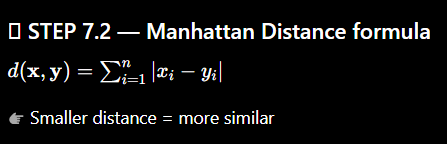

In [4]:
import numpy as np

def manhattan_distance(student, ideal):
    return np.sum(np.abs(np.array(student) - np.array(ideal)))

### Recommendation function (UPGRADE)

In [5]:
def recommend_manhattan(row):
    student_vector = [
        row['Math'],
        row['Programming'],
        row['Database'],
        row['Network'],
        row['GIS'],
        row['Systems']
    ]

    distances = {}

    for track, ideal in ideal_profiles.items():
        distances[track] = manhattan_distance(student_vector, ideal)

    return min(distances, key=distances.get)

df['Recommendation_ML'] = df.apply(recommend_manhattan, axis=1)

In [6]:
df[['Student_ID', 'Recommendation','Recommendation_ML']].head()

,Student_ID,Recommendation,Recommendation_ML
0,S1,Software Engineering,Data Science
1,S2,General IT,Network Engineer
2,S3,General IT,Network Engineer
3,S4,Data Science,Data Science
4,S5,General IT,Software Engineering


#### If distance is smaller, what does it mean?

A smaller Manhattan distance indicates a higher similarity between the student’s feature vector and the ideal profile of a specialization. Therefore, the model selects the specialization with the minimum distance as the predicted class, since it minimizes the difference across all measured attributes.

## 🎯 GOAL OF VISUALIZATION

Not just “pretty chart” ❌
But:

##### “Help us understand how the model behaves”

### What we want to see

We will visualize:

##### 1. Distribution of recommendations

👉 How many students go to each track?

##### 2. Compare Rule vs ML

👉 Are they different?

##### 3. Feature comparison

👉 Why a student gets that recommendation?

In [7]:
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)

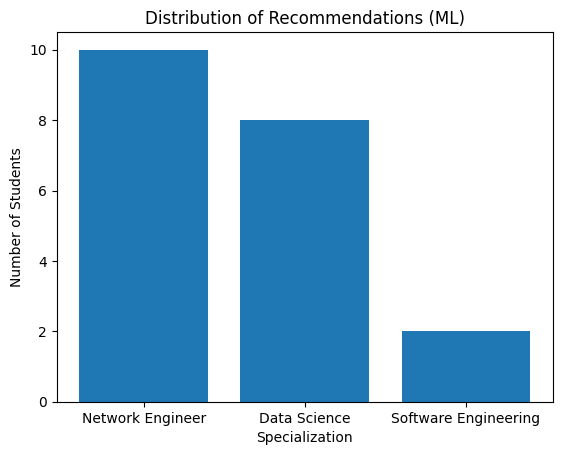

In [8]:
import matplotlib.pyplot as plt

counts = df['Recommendation_ML'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Distribution of Recommendations (ML)")
plt.xlabel("Specialization")
plt.ylabel("Number of Students")
plt.show()

1. The majority of students are recommended toward the Network Engineering specialization, followed by Data Science, while Software Engineering has significantly fewer recommendations. This suggests that most students in the dataset have stronger attributes related to networking skills compared to programming-focused software development.

2. Since the dataset is synthetically generated, the distribution of recommendations may not reflect real-world conditions and can be influenced by how the dummy data and ideal profiles were defined.

#### Ask yourself:

#### 1. Why Network dominates?
Possible reasons:
1. Many students have high Network scores
2. Ideal profile for Network might be easier to match
3. Dataset bias (you created dummy data)

#### 2. Why Software Engineering is low?
1. Requires high Programming + Systems
2. Maybe few students meet that threshold

### 📊 Compare Rule vs ML

In [9]:
pd.crosstab(df['Recommendation'], df['Recommendation_ML'])

Recommendation_ML,Data Science,Network Engineer,Software Engineering
Recommendation,,,
Data Science,7,0,0
General IT,0,5,2
Network Engineer,0,5,0
Software Engineering,1,0,0
